# 02 — Exploratory Data Analysis

Visual companion to the SQL analysis (`01_sql_analysis.ipynb`). Focus: class balance,
how feature distributions differ between churned and retained customers, and which
correlations are worth carrying into feature engineering (Phase 4).

Figures are saved to `reports/figures/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette=["#4c72b0", "#c44e52"])
BASELINE = 10.21  # overall churn rate (%)

df = pd.read_parquet(ROOT / "data" / "interim" / "churn_clean.parquet")
df["status"] = np.where(df["churn"] == 1, "churned", "retained")
df.shape

(10000, 32)

## 1. Target balance

10.21% churn → a ~9:1 imbalance. Accuracy would score 89.8% by predicting "nobody
churns", which is why modeling (Phase 5) is evaluated on PR-AUC / recall instead.

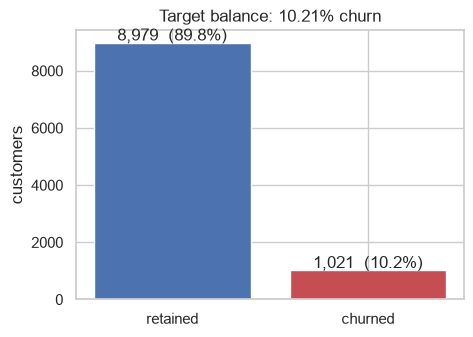

In [2]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["status"].value_counts()
ax.bar(counts.index, counts.values, color=["#4c72b0", "#c44e52"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 80, f"{v:,}  ({v / len(df):.1%})", ha="center")
ax.set_ylabel("customers")
ax.set_title("Target balance: 10.21% churn")
fig.savefig(FIG / "01_target_balance.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Numeric distributions: churned vs retained

Densities are normalised per class (`common_norm=False`) so the 9:1 imbalance doesn't
hide shape differences.

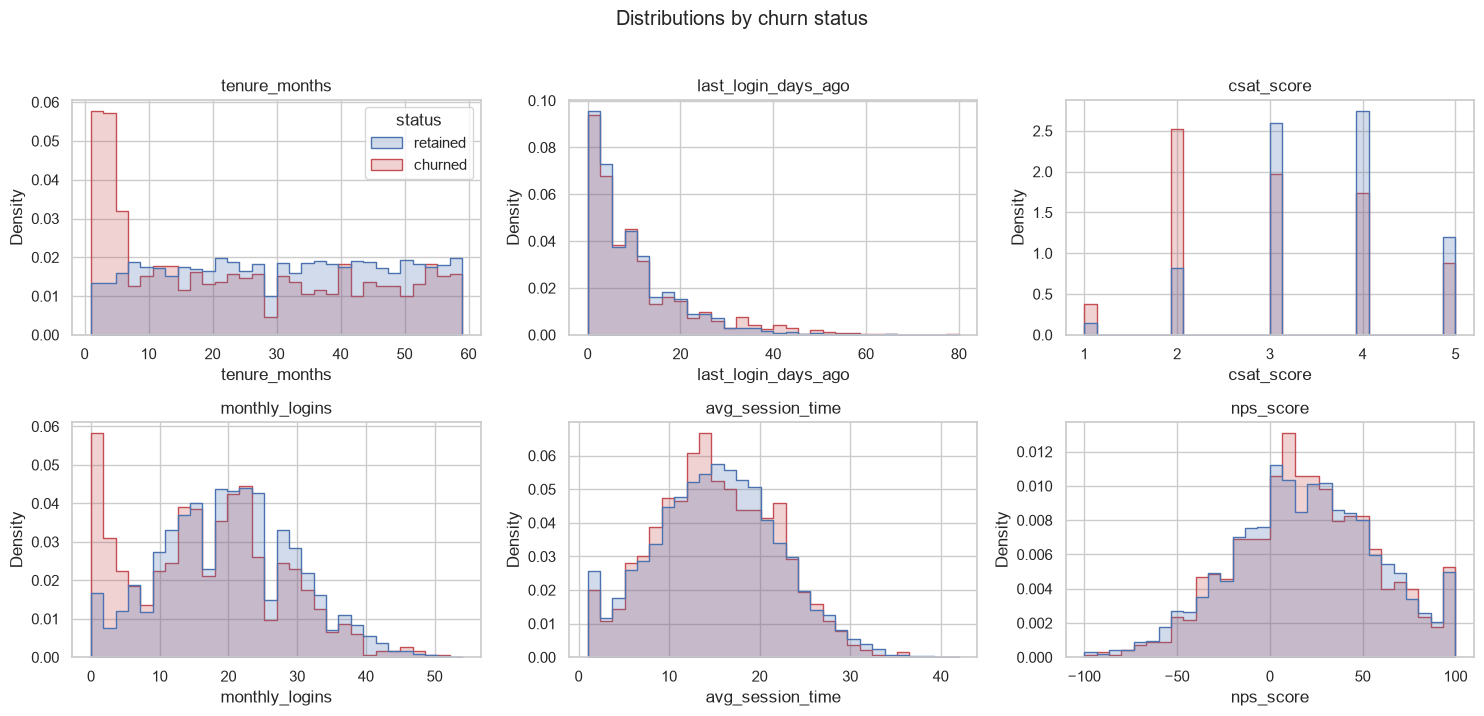

In [3]:
num_cols = [
    "tenure_months", "last_login_days_ago", "csat_score",
    "monthly_logins", "avg_session_time", "nps_score",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(
        data=df, x=col, hue="status", stat="density",
        common_norm=False, element="step", bins=30, ax=ax, legend=(col == num_cols[0]),
    )
    ax.set_title(col)
fig.suptitle("Distributions by churn status", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "02_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** churned customers pile up at **low tenure** and **low CSAT**, with a heavier
tail at high `last_login_days_ago`. Engagement volume (`monthly_logins`,
`avg_session_time`) and `nps_score` look nearly identical across classes — consistent
with the SQL findings.

## 3. Churn rate by category

Bars are churn % per group; the dashed line is the 10.21% baseline. Flat bars = no
signal.

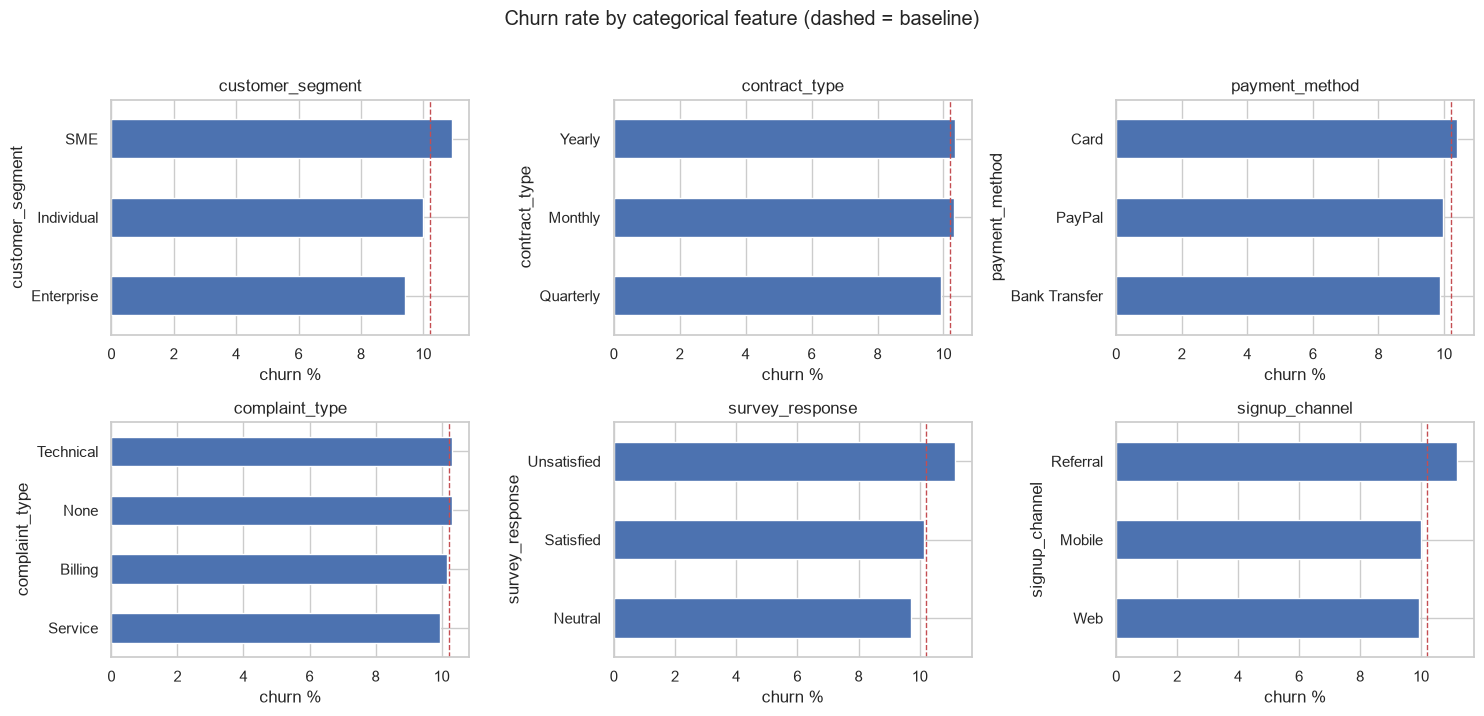

In [4]:
cat_cols = [
    "customer_segment", "contract_type", "payment_method",
    "complaint_type", "survey_response", "signup_channel",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, cat_cols):
    rates = df.groupby(col, observed=True)["churn"].mean().mul(100).sort_values()
    rates.plot.barh(ax=ax, color="#4c72b0")
    ax.axvline(BASELINE, ls="--", c="#c44e52", lw=1)
    ax.set_title(col)
    ax.set_xlabel("churn %")
fig.suptitle("Churn rate by categorical feature (dashed = baseline)", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "03_categorical_churn_rates.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** every categorical hugs the baseline — demographics and plan attributes do
not separate churners in this dataset.

## 4. The four real drivers

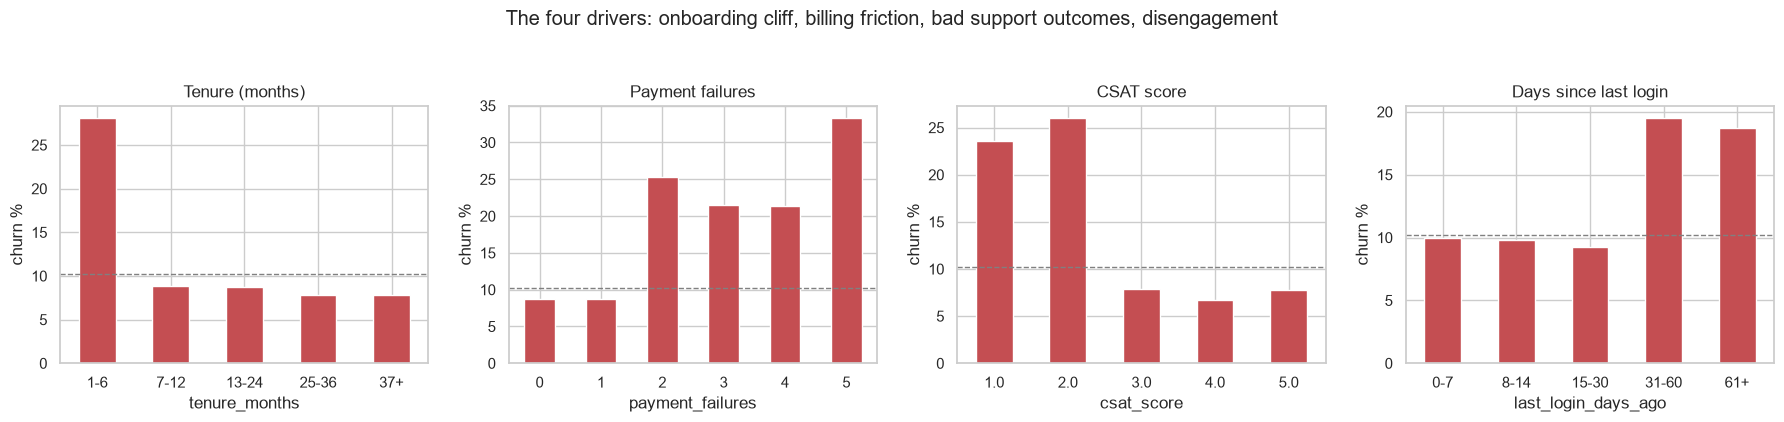

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

tenure = pd.cut(df["tenure_months"], [0, 6, 12, 24, 36, 60],
                labels=["1-6", "7-12", "13-24", "25-36", "37+"])
df.groupby(tenure, observed=True)["churn"].mean().mul(100).plot.bar(
    ax=axes[0], color="#c44e52", rot=0)
axes[0].set_title("Tenure (months)")

df.groupby("payment_failures")["churn"].mean().mul(100).plot.bar(
    ax=axes[1], color="#c44e52", rot=0)
axes[1].set_title("Payment failures")

df.groupby("csat_score")["churn"].mean().mul(100).plot.bar(
    ax=axes[2], color="#c44e52", rot=0)
axes[2].set_title("CSAT score")

recency = pd.cut(df["last_login_days_ago"], [-1, 7, 14, 30, 60, 100],
                 labels=["0-7", "8-14", "15-30", "31-60", "61+"])
df.groupby(recency, observed=True)["churn"].mean().mul(100).plot.bar(
    ax=axes[3], color="#c44e52", rot=0)
axes[3].set_title("Days since last login")

for ax in axes:
    ax.axhline(BASELINE, ls="--", c="grey", lw=1)
    ax.set_ylabel("churn %")
fig.suptitle("The four drivers: onboarding cliff, billing friction, bad support outcomes, disengagement", y=1.05)
fig.tight_layout()
fig.savefig(FIG / "04_key_drivers.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** these four panels *are* the churn story — 28% in the first 6 months, a jump
at the 2nd payment failure, 24–26% at CSAT ≤ 2, and a doubling after 30 days of
inactivity. Phase 4 will encode exactly these thresholds as features.

## 5. Correlation structure (Spearman)

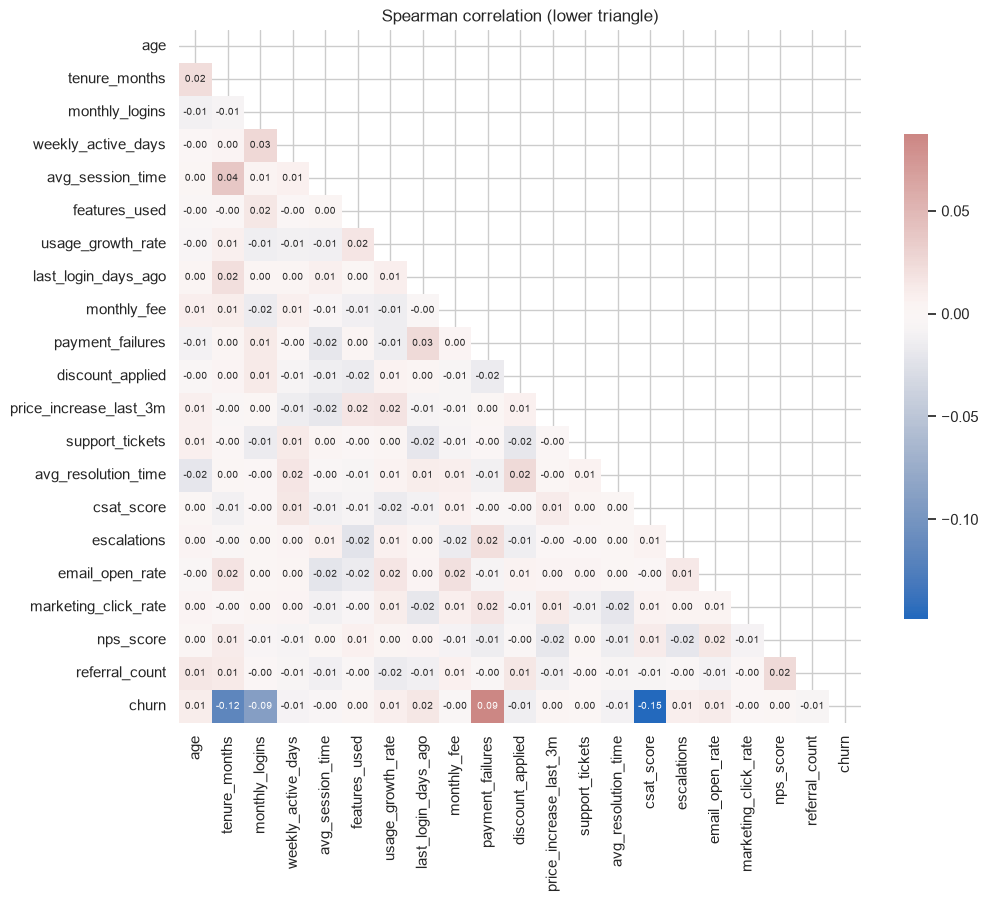

In [6]:
corr = df.select_dtypes("number").corr("spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Spearman correlation (lower triangle)")
fig.savefig(FIG / "05_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** features are mostly uncorrelated with each other (the identity column
`total_revenue` was already removed in Phase 1). `churn` shows its strongest rank
correlations with `tenure_months` (−), `csat_score` (−), `payment_failures` (+) and
`last_login_days_ago` (+) — no single feature dominates, so a model has to combine weak
signals.

## 6. Geography randomness check

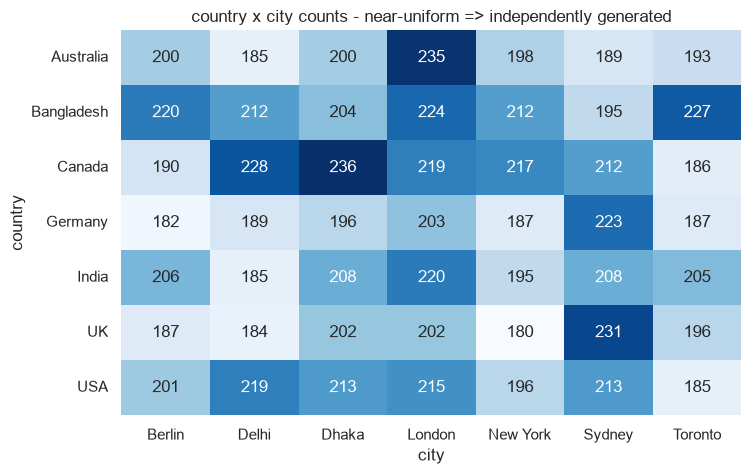

In [7]:
ct = pd.crosstab(df["country"], df["city"])
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("country x city counts - near-uniform => independently generated")
fig.savefig(FIG / "06_geography_random.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** every cell is populated with ~180–235 customers ("Bangladesh / London"
included). The two columns are independent random draws → geography is dropped from
feature engineering.

---
## EDA conclusions

1. **Drivers:** early tenure, ≥2 payment failures, CSAT ≤ 2, >30-day inactivity.
2. **Non-drivers:** demographics, segment, contract, payment method, NPS, ticket volume,
   pricing flags, geography.
3. **Modeling implications:** imbalanced target (PR-AUC, class weights), threshold-shaped
   effects (bucketed features will help linear models), weak individual signals (expect
   modest but honest performance).
4. Next: Phase 3 tests these observations formally (significance + effect size + survival
   analysis).